# 20 — Actor-Critic, TD Learning, and GAE

## Goal

REINFORCE learns from complete Monte Carlo returns.

This is unbiased with respect to the sampled trajectory return, but it
can have high variance and may require waiting until the end of an
episode.

This lesson introduces bootstrapping:

> Instead of waiting for the entire future, can we use a learned estimate
> of the future?

We will build the ideas in stages:

1. Monte Carlo targets versus bootstrapped targets,
2. temporal-difference learning,
3. the TD error,
4. learning a critic,
5. actor-critic updates,
6. multi-step returns,
7. the bias-variance trade-off,
8. and generalized advantage estimation.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## 1. From Monte Carlo Returns to Bootstrapping

Monte Carlo learning uses the realized return

$$
G_t
=
r_t
+
\gamma r_{t+1}
+
\gamma^2 r_{t+2}
+
\cdots.
$$

This target contains real sampled rewards from the future.

However, it may require waiting until the trajectory ends.

Suppose we already have an estimate

$$
V_\phi(s)
$$

of expected future return.

Then after observing only one transition

$$
s_t
\xrightarrow{a_t}
(r_t,s_{t+1}),
$$

we can form the target

$$
r_t
+
\gamma
V_\phi(s_{t+1}).
$$

This replaces the unknown distant future with a current estimate of that
future.

## 2. The Temporal-Difference Error

The one-step TD target is

$$
y_t^{\text{TD}}
=
r_t
+
\gamma
V_\phi(s_{t+1}).
$$

The current prediction is

$$
V_\phi(s_t).
$$

Their difference is the temporal-difference error:

$$
\delta_t
=
r_t
+
\gamma
V_\phi(s_{t+1})
-
V_\phi(s_t).
$$

Interpretation:

- $\delta_t > 0$: the transition was better than the critic expected,
- $\delta_t < 0$: the transition was worse than expected,
- $\delta_t \approx 0$: the critic's prediction was locally consistent
  with the observed transition.

In [2]:
reward: float = 0.0
gamma: float = 1.0

value_current: float = 0.5
value_next: float = 0.7

td_target: float = reward + gamma * value_next

td_error: float = td_target - value_current

print("TD target:", td_target)

TD target: 0.7


In [3]:
def td_error(
    reward: float, value: float, next_value: float, gamma: float
) -> float:
    """Compute a one-step temporal-difference error.

    Args:
        reward: Immediate observed reward.
        value: Current value estimate V(s_t).
        next_value: Next-state value estimate V(s_{t+1}).
        gamma: Discount factor.

    Returns:
        One-step TD error.
    """

    if not 0.0 <= gamma <= 1.0:
        raise ValueError("gamma must be between 0 and 1.")

    return reward + gamma * next_value - value

In [4]:
delta_leave: float = td_error(
    reward=1.0, value=0.875, next_value=0.0, gamma=1.0
)

delta_continue: float = td_error(
    reward=0.0, value=0.875, next_value=0.75, gamma=1.0
)

print("leave:", delta_leave)

print("continue:", delta_continue)

leave: 0.125
continue: -0.125


## 3. Actor and Critic

The policy is the actor:

$$
\pi_\theta(a\mid s).
$$

It decides how actions are sampled.

A learned value function is the critic:

$$
V_\phi(s).
$$

It predicts expected future return.

The actor asks:

> What should I do?

The critic asks:

> How good is the situation I am in?

The TD error connects them:

$$
\delta_t
=
r_t
+
\gamma V_\phi(s_{t+1})
-
V_\phi(s_t).
$$

In [5]:
values = nn.Parameter(torch.tensor([0.0, 0.0]))

## 4. Time Alignment Before a Critic

Before implementing a critic, we need to make the temporal alignment of
states, actions, rewards, and values explicit.

For a trajectory with $T$ actions, there are

$$
T+1
$$

states:

$$
s_0
\xrightarrow{a_0,r_0}
s_1
\xrightarrow{a_1,r_1}
\cdots
\xrightarrow{a_{T-1},r_{T-1}}
s_T.
$$

Therefore:

- actions have length $T$,
- rewards have length $T$,
- values naturally have length $T+1$,
- TD targets have length $T$,
- TD errors have length $T$.

The extra value corresponds to the state reached after the final action.

In [6]:
rewards = torch.tensor([0.0, 3.0])

values = torch.tensor([0.875, 0.75, 0.0])

gamma: float = 1.0

print("rewards:", rewards.shape)

print("values:", values.shape)

rewards: torch.Size([2])
values: torch.Size([3])


In [7]:
current_values: torch.Tensor = values[:-1]

next_values: torch.Tensor = values[1:]

print("current:", current_values)

print("next:", next_values)

current: tensor([0.8750, 0.7500])
next: tensor([0.7500, 0.0000])


In [8]:
td_targets: torch.Tensor = rewards + gamma * next_values
td_errors: torch.Tensor = td_targets - current_values

print(td_targets)
print(td_errors)

tensor([0.7500, 3.0000])
tensor([-0.1250,  2.2500])


### The Future Rollout Contract

For a batch of trajectories with $T$ generated actions:

$$
\text{rewards}
\in
\mathbb R^{B\times T},
$$

while value predictions naturally include one additional state:

$$
\text{values}
\in
\mathbb R^{B\times(T+1)}.
$$

Therefore,

$$
V_{\text{current}}
=
\text{values}[:, :-1],
$$

and

$$
V_{\text{next}}
=
\text{values}[:, 1:].
$$

A bootstrap-aware TD target has the form

$$
y_t
=
r_t
+
\gamma
m_t
V(s_{t+1}),
$$

where $m_t$ determines whether future value is allowed to bootstrap
through the transition.

## 5. A Minimal Critic

A critic is a trainable function

$$
V_\phi(s)
$$

that predicts expected future return from a state.

Our tiny environment has only two non-terminal states, so we do not need
a neural network that generalizes between states.

Instead, we can learn one scalar parameter for each state.

The important idea is not the architecture.

It is the interface:

<pre>
state
    ↓
Critic(nn.Module)
    ↓
scalar value estimate
</pre>

Later, a language-model critic will use a neural representation of a
token prefix instead of a tabular state index, but the interface remains
the same.

In [9]:
class TabularCritic(nn.Module):
    """Learn one scalar value for each discrete non-terminal state.

    Args:
        num_states: Number of trainable discrete states.
    """

    def __init__(self, num_states: int) -> None:
        super().__init__()

        if num_states <= 0:
            raise ValueError("num_states must be > 0")

        self.value_table = nn.Embedding(num_states, 1)

        nn.init.zeros_(self.value_table.weight)

    def forward(self, state_indices: torch.Tensor) -> torch.Tensor:
        """Return scalar value estimates for state indices.

        Args:
            state_indices: Integer tensor containing discrete state IDs.

        Returns:
            Value estimates with the same leading shape as `state_indices`.
        """
        values: torch.Tensor = self.value_table(state_indices)

        return values.squeeze(dim=-1)

In [10]:
state_to_index: dict[str, int] = {"s0": 0, "s1": 1}

critic = TabularCritic(num_states=2)

print(critic.value_table.weight.detach())

tensor([[0.],
        [0.]])


In [11]:
s1_action_probabilities = torch.tensor([0.25, 0.75])

s1_rewards = torch.tensor([3.0, 0.0])


sampled_action: int = int(
    torch.multinomial(s1_action_probabilities, num_samples=1).item()
)

reward: torch.Tensor = s1_rewards[sampled_action]

print("action:", sampled_action)

print("reward:", reward.item())

action: 1
reward: 0.0


In [12]:
state_index = torch.tensor(state_to_index["s1"])

value_prediction: torch.Tensor = critic(state_index)

print("V(s1):", value_prediction.item())

V(s1): 0.0


In [13]:
next_value = torch.tensor(0.0)

td_target: torch.Tensor = reward + gamma * next_value

print(td_target)

tensor(0.)


In [14]:
value_loss: torch.Tensor = (
    0.5 * (value_prediction - td_target.detach()).square()
)

In [15]:
critic_optimizer = torch.optim.SGD(critic.parameters(), lr=0.1)

critic_optimizer.zero_grad()

value_loss.backward()

critic_optimizer.step()

print(critic.value_table.weight.detach())

tensor([[0.],
        [0.]])


In [16]:
torch.manual_seed(0)

critic = TabularCritic(num_states=2)

critic_optimizer = torch.optim.SGD(critic.parameters(), lr=0.05)

num_updates: int = 2_000

s1_value_history: list[float] = []

for _ in range(num_updates):
    sampled_action: int = int(
        torch.multinomial(s1_action_probabilities, num_samples=1).item()
    )

    reward: torch.Tensor = s1_rewards[sampled_action]

    state_index = torch.tensor(state_to_index["s1"])

    value_prediction: torch.Tensor = critic(state_index)

    td_target: torch.Tensor = reward

    value_loss: torch.Tensor = (
        0.5 * (value_prediction - td_target.detach()).square()
    )

    critic_optimizer.zero_grad()

    value_loss.backward()

    critic_optimizer.step()

    s1_value_history.append(critic(state_index).detach().item())

In [17]:
print(
    "learned V(s1):",
    critic(torch.tensor(state_to_index["s1"])).detach().item(),
)

print("true V(s1):", 0.75)

learned V(s1): 0.8252061009407043
true V(s1): 0.75


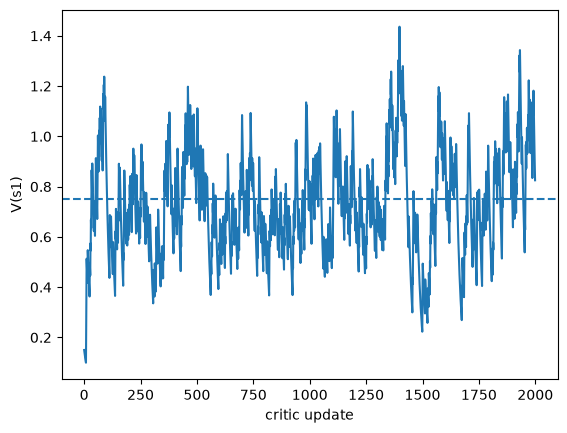

In [18]:
plt.figure()

plt.plot(s1_value_history)

plt.axhline(0.75, linestyle="--")

plt.xlabel("critic update")

plt.ylabel("V(s1)")

plt.show()

## 6. A Minimal Actor

The actor represents the policy

$$
\pi_\theta(a\mid s).
$$

Like the tabular critic, our tiny environment does not require a neural
network that generalizes between states.

We therefore learn one vector of action logits for every discrete state.

The actor interface is

<pre>
state
    ↓
Actor(nn.Module)
    ↓
action logits
    ↓
policy distribution
</pre>

This mirrors the language-model case, where a token prefix is mapped to
vocabulary logits.

In [19]:
class TabularActor(nn.Module):
    """Learn action logits for each discrete state.

    Args:
        num_states: Number of discrete non-terminal states.
        num_actions: Number of available actions per state.
    """

    def __init__(self, num_states: int, num_actions: int) -> None:
        super().__init__()

        if num_states <= 0:
            raise ValueError("num_states must be positive.")
        if num_actions <= 0:
            raise ValueError("num_actions must be positive.")

        self.logit_table = nn.Embedding(num_states, num_actions)

        # Start with equal action probabilities in every state.
        nn.init.zeros_(self.logit_table.weight)

    def forward(self, state_indices: torch.Tensor) -> torch.Tensor:
        """Return policy logits for discrete states.

        Args:
            state_indices: Integer tensor containing discrete state IDs.

        Returns:
            Action logits with one final action dimension.
        """
        return self.logit_table(state_indices)

In [20]:
action_names: dict[str, tuple[str, str]] = {
    "s0": ("leave", "continue"),
    "s1": ("left", "right"),
}

actor = TabularActor(num_states=2, num_actions=2)

s0_index = torch.tensor(state_to_index["s0"])

s0_logits: torch.Tensor = actor(s0_index)

s0_probabilities: torch.Tensor = torch.softmax(s0_logits, dim=-1)

print("logits:", s0_logits.detach())

print("probabilities:", s0_probabilities.detach())

logits: tensor([0., 0.])
probabilities: tensor([0.5000, 0.5000])


## 7. One Transition, Two Learning Signals

The TD error

$$
\delta_t
=
r_t
+
\gamma V_\phi(s_{t+1})
-
V_\phi(s_t)
$$

connects the actor and critic.

For the critic, it is a prediction error.

For the actor, it acts as a one-step advantage estimate.

Therefore one transition produces two losses:

$$
\mathcal L_V
=
\frac12
\delta_t^2,
$$

and

$$
\mathcal L_\pi
=
-
\delta_t
\log
\pi_\theta(a_t\mid s_t).
$$

The actor treats the TD error as a fixed credit signal, so the TD error
is detached in the policy loss.

In [21]:
state_index = torch.tensor(state_to_index["s1"])

logits: torch.Tensor = actor(state_index)

probabilities: torch.Tensor = torch.softmax(logits, dim=-1)

sampled_action: int = int(
    torch.multinomial(probabilities.detach(), num_samples=1).item()
)

reward: torch.Tensor = s1_rewards[sampled_action]

current_value: torch.Tensor = critic(state_index)

next_value = torch.tensor(0.0)

td_target: torch.Tensor = reward + gamma * next_value

delta: torch.Tensor = td_target.detach() - current_value

critic_loss: torch.Tensor = 0.5 * delta.square()

log_probabilities: torch.Tensor = torch.log_softmax(logits, dim=-1)

sampled_log_probability: torch.Tensor = log_probabilities[sampled_action]

actor_loss: torch.Tensor = -delta.detach() * sampled_log_probability

In [22]:
actor_optimizer = torch.optim.SGD(actor.parameters(), lr=0.05)

critic_optimizer = torch.optim.SGD(critic.parameters(), lr=0.1)

In [23]:
actor_optimizer.zero_grad()
critic_optimizer.zero_grad()
actor_loss.backward()
critic_loss.backward()
actor_optimizer.step()
critic_optimizer.step()

## 8. Closing the Actor-Critic Loop

So far, we have examined one actor-critic update in isolation.

We now let the actor interact repeatedly with the tiny environment.

Each transition follows the same cycle:

<pre>
state
    ↓
actor produces a policy
    ↓
sample action
    ↓
environment returns reward and next state
    ↓
critic computes TD error
    ↓
critic updates its value estimate
    ↓
actor uses the detached TD error as credit
    ↓
policy changes
</pre>

This creates a feedback loop:

the policy determines which experience is collected, while that
experience changes both the policy and the value function.

In [24]:
def step_tiny_environment(
    state: str, action_index: int
) -> tuple[str, float, bool]:
    """Apply one action in the tiny deterministic environment.

    Args:
        state: Current non-terminal state.
        action_index: Integer action selected by the actor.

    Returns:
        Tuple `(next_state, reward, terminated)`.
    """
    if state == "s0":
        if action_index == 0:
            return ("terminal", 1.0, True)

        if action_index == 1:
            return ("s1", 0.0, False)

    if state == "s1":
        if action_index == 0:
            return ("terminal", 3.0, True)

        if action_index == 1:
            return ("terminal", 0.0, True)

    raise ValueError("Unknown state or action.")

In [25]:
torch.manual_seed(0)

actor = TabularActor(num_states=2, num_actions=2)

critic = TabularCritic(
    num_states=2,
)

actor_optimizer = torch.optim.SGD(actor.parameters(), lr=0.05)

critic_optimizer = torch.optim.SGD(critic.parameters(), lr=0.1)

gamma: float = 1.0

num_episodes: int = 2_000

In [26]:
continue_probability_history: list[float] = []
left_probability_history: list[float] = []

s0_value_history: list[float] = []
s1_value_history: list[float] = []

episode_return_history: list[float] = []

In [27]:
for _ in range(num_episodes):
    state: str = "s0"
    terminated: bool = False

    episode_return: float = 0.0

    while not terminated:
        state_index = torch.tensor(state_to_index[state])

        # ------------------------------------------------------------
        # Actor: produce and sample the current policy.
        # ------------------------------------------------------------

        logits: torch.Tensor = actor(state_index)

        probabilities: torch.Tensor = torch.softmax(
            logits,
            dim=-1,
        )

        sampled_action: int = int(
            torch.multinomial(
                probabilities.detach(),
                num_samples=1,
            ).item()
        )

        # ------------------------------------------------------------
        # Environment: execute the sampled action.
        # ------------------------------------------------------------

        (
            next_state,
            reward,
            terminated,
        ) = step_tiny_environment(
            state,
            sampled_action,
        )

        episode_return += reward

        # ------------------------------------------------------------
        # Critic: estimate current and next-state values.
        # ------------------------------------------------------------

        current_value: torch.Tensor = critic(state_index)

        if terminated:
            next_value = torch.tensor(0.0)

        else:
            next_state_index = torch.tensor(state_to_index[next_state])

            with torch.no_grad():
                next_value = critic(next_state_index)

        # ------------------------------------------------------------
        # TD target and TD error.
        # ------------------------------------------------------------

        td_target: torch.Tensor = torch.tensor(reward) + gamma * next_value

        delta: torch.Tensor = td_target - current_value

        # ------------------------------------------------------------
        # Actor loss: TD error acts as a one-step advantage estimate.
        # ------------------------------------------------------------

        log_probabilities: torch.Tensor = torch.log_softmax(
            logits,
            dim=-1,
        )

        sampled_log_probability: torch.Tensor = log_probabilities[
            sampled_action
        ]

        actor_loss: torch.Tensor = -delta.detach() * sampled_log_probability

        # ------------------------------------------------------------
        # Critic loss: regress V(s_t) toward the fixed TD target.
        # ------------------------------------------------------------

        critic_loss: torch.Tensor = 0.5 * delta.square()

        # ------------------------------------------------------------
        # Update the two independent parameter sets.
        # ------------------------------------------------------------

        actor_optimizer.zero_grad()
        critic_optimizer.zero_grad()

        actor_loss.backward()
        critic_loss.backward()

        actor_optimizer.step()
        critic_optimizer.step()

        state = next_state

    with torch.no_grad():
        s0_index = torch.tensor(state_to_index["s0"])

        s1_index = torch.tensor(state_to_index["s1"])

        s0_probabilities = torch.softmax(
            actor(s0_index),
            dim=-1,
        )

        s1_probabilities = torch.softmax(
            actor(s1_index),
            dim=-1,
        )

        continue_probability_history.append(s0_probabilities[1].item())

        left_probability_history.append(s1_probabilities[0].item())

        s0_value_history.append(critic(s0_index).item())

        s1_value_history.append(critic(s1_index).item())

    episode_return_history.append(episode_return)

In [28]:
print("P(continue | s0):", continue_probability_history[-1])

print("P(left | s1):", left_probability_history[-1])

print("V(s0):", s0_value_history[-1])

print("V(s1):", s1_value_history[-1])

P(continue | s0): 0.9976440072059631
P(left | s1): 0.9992208480834961
V(s0): 2.999998092651367
V(s1): 2.9999990463256836


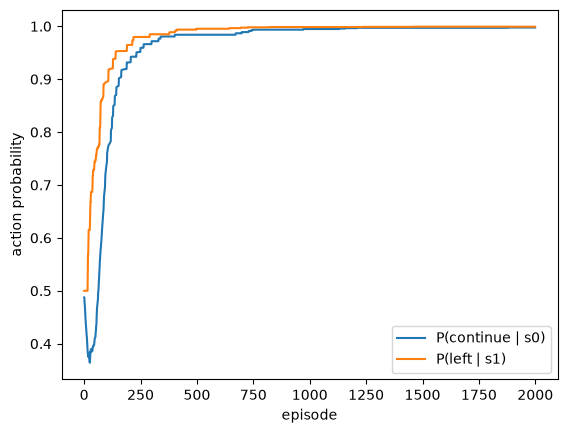

In [29]:
plt.figure()

plt.plot(continue_probability_history, label="P(continue | s0)")

plt.plot(left_probability_history, label="P(left | s1)")

plt.xlabel("episode")

plt.ylabel("action probability")

plt.legend()

plt.show()

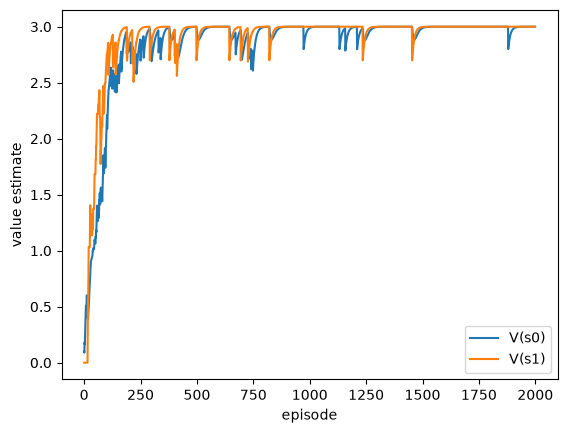

In [30]:
plt.figure()

plt.plot(s0_value_history, label="V(s0)")

plt.plot(s1_value_history, label="V(s1)")

plt.xlabel("episode")

plt.ylabel("value estimate")

plt.legend()

plt.show()

### The Target Moves Because the Policy Moves

In supervised learning, the target labels are usually fixed while the
model changes.

In actor-critic reinforcement learning, the policy determines which
experience is collected.

As the policy changes, the state-value function of that policy also
changes.

Therefore the critic is not learning a permanently fixed function.

It tracks

$$
V^{\pi_\theta}(s),
$$

while the actor is simultaneously changing

$$
\pi_\theta.
$$

This creates a coupled learning system:

<pre>
actor changes
    ↓
behavior changes
    ↓
experience distribution changes
    ↓
true state values change
    ↓
critic adapts
    ↓
advantage estimates change
    ↓
actor changes again
</pre>

## 9. n-Step Returns

One-step TD uses one observed reward before bootstrapping:

$$
G_t^{(1)}
=
r_t
+
\gamma V(s_{t+1}).
$$

Monte Carlo waits for the complete sampled future.

These are not the only possibilities.

An $n$-step return uses $n$ observed rewards and then bootstraps from a
value estimate:

$$
G_t^{(n)}
=
\sum_{k=0}^{n-1}
\gamma^k r_{t+k}
+
\gamma^n
V(s_{t+n}).
$$

If the trajectory terminates before the bootstrap state, the terminal
value is zero.

In [31]:
def n_step_return(
    rewards: list[float],
    bootstrap_value: float,
    gamma: float,
) -> float:
    """Compute an n-step return from observed rewards and a bootstrap value.

    Args:
        rewards: Consecutive rewards from the current time step onward.
        bootstrap_value: Value estimate after the final supplied reward.
        gamma: Discount factor in the interval `[0, 1]`.

    Returns:
        n-step bootstrapped return.
    """
    if not rewards:
        raise ValueError("rewards must contain at least one observed reward.")

    if not 0.0 <= gamma <= 1.0:
        raise ValueError("gamma must be between 0 and 1.")

    result: float = bootstrap_value

    for reward in reversed(rewards):
        result = reward + gamma * result

    return result

In [32]:
one_step: float = n_step_return(
    rewards=[1.0],
    bootstrap_value=5.0,
    gamma=0.9,
)

two_step: float = n_step_return(
    rewards=[1.0, 0.0], bootstrap_value=4.0, gamma=0.9
)

three_step: float = n_step_return(
    rewards=[1.0, 0.0, 2.0], bootstrap_value=3.0, gamma=0.9
)

monte_carlo: float = n_step_return(
    rewards=[1.0, 0.0, 2.0, 4.0], bootstrap_value=0.0, gamma=0.9
)

print("1-step:", one_step)

print("2-step:", two_step)

print("3-step:", three_step)

print("Monte Carlo:", monte_carlo)

1-step: 5.5
2-step: 4.24
3-step: 4.807
Monte Carlo: 5.5360000000000005


### n-Step Returns Form a Continuum

The number of observed rewards determines how strongly the target relies
on bootstrapping.

<pre>
small n
    ↓
more critic bootstrapping
    ↓
usually lower variance
    ↓
more sensitivity to value-estimation bias


large n
    ↓
more sampled rewards
    ↓
usually higher variance
    ↓
less bootstrap bias


full trajectory
    ↓
Monte Carlo
</pre>

This suggests a new question:

> Instead of choosing one fixed horizon, can multiple n-step targets be
> combined?

That idea leads to TD($\lambda$) and, shortly afterwards, GAE.

## 10. TD(lambda): Mixing Multiple Horizons

Different n-step returns trade off bootstrapping bias and sampled
variance.

Instead of choosing exactly one horizon, TD($\lambda$) combines multiple
n-step returns.

The parameter

$$
\lambda\in[0,1]
$$

controls how much weight is placed on longer sampled futures.

Small $\lambda$ emphasizes short bootstrapped targets.

Large $\lambda$ emphasizes longer sampled returns.

In [33]:
def lambda_return(n_step_returns: list[float], lambda_: float) -> float:
    """Mix finite-horizon n-step returns using TD(lambda) weights.

    Args:
        n_step_returns: Returns ordered from shortest to longest horizon.
        lambda_: Mixing coefficient in the interval `[0, 1]`.

    Returns:
        Finite-horizon lambda-return.
    """
    if not n_step_returns:
        raise ValueError("n_step_returns must not be empty")

    if not 0.0 <= lambda_ <= 1.0:
        raise ValueError("lambda_ must be between 0 and 1.")

    result: float = 0.0

    last_index: int = len(n_step_returns) - 1

    for index, n_step_value in enumerate(n_step_returns):
        if index == last_index:
            weight: float = lambda_**index

        else:
            weight = (1.0 - lambda_) * lambda_**index

        result += weight * n_step_value

    return result

In [34]:
n_step_values: list[float] = [5.5, 4.24, 4.807]

print("lambda = 0:", lambda_return(n_step_values, lambda_=0.0))
print("lambda = 1:", lambda_return(n_step_values, lambda_=1.0))
print("lambda = 0.5:", lambda_return(n_step_values, lambda_=0.5))

lambda = 0: 5.5
lambda = 1: 4.807
lambda = 0.5: 5.01175


## 11. Generalized Advantage Estimation

An n-step return estimates future return using $n$ sampled rewards before
bootstrapping.

For policy learning, we care about advantage rather than absolute return.

Define the n-step advantage estimate

$$
\hat A_t^{(n)}
=
G_t^{(n)}
-
V(s_t).
$$

The key observation is that n-step advantage estimates can be rewritten
as sums of temporal-difference errors.

This leads directly to generalized advantage estimation.

### n-Step Advantages as TD-Error Sums

For one step,

$$
\hat A_t^{(1)}
=
\delta_t.
$$

For two steps,

$$
\hat A_t^{(2)}
=
\delta_t
+
\gamma\delta_{t+1}.
$$

For three steps,

$$
\hat A_t^{(3)}
=
\delta_t
+
\gamma\delta_{t+1}
+
\gamma^2\delta_{t+2}.
$$

In general,

$$
\hat A_t^{(n)}
=
\sum_{l=0}^{n-1}
\gamma^l
\delta_{t+l}.
$$

An n-step advantage estimate can therefore be interpreted as a sum of
future TD errors.

### Recursive Form of GAE

For a finite trajectory, GAE can be computed backwards:

$$
\hat A_t
=
\delta_t
+
\gamma\lambda
m_t
\hat A_{t+1},
$$

where $m_t$ determines whether credit is allowed to propagate through
the transition.

This recursion is why GAE is naturally computed from the end of a
trajectory toward the beginning.

## 12. Implementing Generalized Advantage Estimation

For a complete trajectory, define the one-step TD error

$$
\delta_t
=
r_t
+
\gamma m_t V(s_{t+1})
-
V(s_t),
$$

where $m_t$ is zero after a true terminal transition and one otherwise.

GAE is then computed backwards:

$$
\hat A_t
=
\delta_t
+
\gamma\lambda m_t
\hat A_{t+1}.
$$

The reverse recursion propagates later TD errors backward toward earlier
actions while geometrically reducing their influence.

In [35]:
def generalized_advantage_estimate(
    rewards: torch.Tensor,
    values: torch.Tensor,
    bootstrap_mask: torch.Tensor,
    gamma: float,
    lambda_: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute GAE advantages and corresponding value targets.

    Args:
        rewards: Rewards with shape `(T,)`.
        values: State values with shape `(T + 1,)`.
        bootstrap_mask: One for transitions that may bootstrap from the next
            state and zero for true terminal transitions. Shape `(T,)`.
        gamma: Discount factor in `[0, 1]`.
        lambda_: GAE mixing parameter in `[0, 1]`.

    Returns:
        A tuple `(advantages, value_targets)`, each with shape `(T,)`.
    """
    if rewards.ndim != 1:
        raise ValueError("rewards must have shape (T,)")

    if values.ndim != 1:
        raise ValueError("values must have shape (T + 1, )")

    if bootstrap_mask.ndim != 1:
        raise ValueError("bootstrap_mask must have shape (T,)")

    if values.shape[0] != rewards.shape[0] + 1:
        raise ValueError("values must contain one more entry than rewards.")

    if bootstrap_mask.shape != rewards.shape:
        raise ValueError("bootstrap_mask must match rewards")

    if not 0.0 <= gamma <= 1.0:
        raise ValueError("gamma must be between 0 and 1.")

    if not 0.0 <= lambda_ <= 1.0:
        raise ValueError("lambda_ must be between 0 and 1.")

    current_values: torch.Tensor = values[:-1]
    next_values: torch.Tensor = values[1:]

    td_errors: torch.Tensor = (
        rewards + gamma * bootstrap_mask * next_values - current_values
    )

    advantages: torch.Tensor = torch.zeros_like(rewards)

    running_advantage = torch.tensor(
        0.0, dtype=rewards.dtype, device=rewards.device
    )

    for time_step in reversed(range(rewards.shape[0])):
        running_advantage = (
            td_errors[time_step]
            + gamma * lambda_ * bootstrap_mask[time_step] * running_advantage
        )
        advantages[time_step] = running_advantage

    value_targets: torch.Tensor = advantages + current_values

    return advantages, value_targets

In [36]:
rewards = torch.tensor([1.0, 2.0, 3.0])

values = torch.tensor([0.5, 0.8, 1.2, 0.0])

bootstrap_mask = torch.tensor([1.0, 1.0, 0.0])

gamma: float = 0.9

current_values = values[:-1]

next_values = values[1:]

expected_td_errors = (
    rewards + gamma * bootstrap_mask * next_values - current_values
)

advantages_lambda_0, _ = generalized_advantage_estimate(
    rewards=rewards,
    values=values,
    bootstrap_mask=bootstrap_mask,
    gamma=gamma,
    lambda_=0.0,
)

print("TD errors:", expected_td_errors)

print("GAE lambda=0:", advantages_lambda_0)

assert torch.allclose(advantages_lambda_0, expected_td_errors)

TD errors: tensor([1.2200, 2.2800, 1.8000])
GAE lambda=0: tensor([1.2200, 2.2800, 1.8000])


In [37]:
from llmfp.rl import discounted_returns

monte_carlo_returns = torch.tensor(
    discounted_returns(
        rewards.tolist(),
        gamma=gamma,
    )
)

expected_mc_advantages: torch.Tensor = monte_carlo_returns - values[:-1]

In [38]:
advantages_lambda_1, value_targets_lambda_1 = generalized_advantage_estimate(
    rewards=rewards,
    values=values,
    bootstrap_mask=bootstrap_mask,
    gamma=gamma,
    lambda_=1.0,
)

print("Monte Carlo advantage:", expected_mc_advantages)

print("GAE lambda=1:", advantages_lambda_1)

Monte Carlo advantage: tensor([4.7300, 3.9000, 1.8000])
GAE lambda=1: tensor([4.7300, 3.9000, 1.8000])


In [39]:
assert torch.allclose(advantages_lambda_1, expected_mc_advantages, atol=1e-6)

assert torch.allclose(value_targets_lambda_1, monte_carlo_returns, atol=1e-6)

In [40]:
rewards = torch.tensor([1.0, 100.0])

values = torch.tensor([0.0, 0.0, 0.0])

bootstrap_mask = torch.tensor([0.0, 0.0])

advantages, _ = generalized_advantage_estimate(
    rewards=rewards,
    values=values,
    bootstrap_mask=bootstrap_mask,
    gamma=1.0,
    lambda_=1.0,
)

print(advantages)

assert torch.allclose(
    advantages,
    torch.tensor([1.0, 100.0]),
)

tensor([  1., 100.])


In [41]:
for lambda_ in [0.0, 0.25, 0.5, 0.75, 1.0]:
    advantages, _ = generalized_advantage_estimate(
        rewards=rewards,
        values=values,
        bootstrap_mask=bootstrap_mask,
        gamma=gamma,
        lambda_=lambda_,
    )

    print(f"lambda={lambda_:.2f}:", advantages)

lambda=0.00: tensor([  1., 100.])
lambda=0.25: tensor([  1., 100.])
lambda=0.50: tensor([  1., 100.])
lambda=0.75: tensor([  1., 100.])
lambda=1.00: tensor([  1., 100.])


In [42]:
rewards = torch.tensor([1.0, 2.0, 3.0])

values = torch.tensor([0.5, 0.8, 1.2, 0.0])

bootstrap_mask = torch.tensor([1.0, 1.0, 0.0])

## 13. Mapping Actor-Critic and GAE to LLM Rollouts

The reinforcement-learning quantities developed in this lesson must
eventually align with generated token positions.

For an autoregressive language model:

$$
s_t
=
(\text{prompt}, y_{<t}),
$$

and

$$
a_t
=
y_t.
$$

For each generated token, the rollout therefore needs to connect:

<pre>
state before the token
        ↓
sampled token
        ↓
old policy log-probability
        ↓
reward
        ↓
critic value
        ↓
advantage / value target
</pre>

The key engineering problem is tensor alignment, not a new RL equation.

### Policy Alignment

A generated token is predicted from the representation immediately
before that token.

For

<pre>
prompt:      A B
completion:  C D E
</pre>

the action alignment is

<pre>
state A B       → logits at B → action C
state A B C     → logits at C → action D
state A B C D   → logits at D → action E
</pre>

Therefore, policy log-probabilities must be aligned with the state that
existed before each generated action.

In [43]:
token_ids = torch.tensor([10, 11, 20, 21, 22])
prompt_length: int = 2
action_token_ids: torch.Tensor = token_ids[prompt_length:]

print(action_token_ids)

tensor([20, 21, 22])


In [44]:
old_log_probs = torch.tensor([-0.5, -0.8, -0.3])

rewards = torch.tensor([0.0, 0.0, 1.0])

rollout_values = torch.tensor([0.20, 0.35, 0.70, 0.00])

In [45]:
bootstrap_mask = torch.tensor([1.0, 1.0, 0.0])
advantages, value_targets = generalized_advantage_estimate(
    rewards=rewards,
    values=rollout_values,
    bootstrap_mask=bootstrap_mask,
    gamma=1.0,
    lambda_=0.95,
)

### Three Different Kinds of Quantities

The framework must distinguish three categories.

#### Collection-time facts

<pre>
sampled tokens
old log-probabilities
rewards
rollout-time values
trajectory boundaries
</pre>

These describe what happened when the rollout was generated.

#### Fixed learning targets

<pre>
advantages
value targets
</pre>

These are computed from the rollout and held fixed during an update.

#### Current differentiable predictions

<pre>
current log-probabilities
current value predictions
</pre>

These are recomputed from the current actor and critic during training
and carry the autograd graph.

Confusing these three categories can produce training code that runs
without optimizing the intended objective.

### Planned Rollout Tensor Contract

For a batch of $B$ trajectories with up to $T$ generated actions, the
minimal online-RL path will eventually need quantities such as

<pre>
sequence_ids           complete prompt + completion sequences
action_positions       positions of generated tokens
action_mask             valid generated-action positions

old_log_probs          (B, T)
rewards                (B, T)
rollout_values         (B, T + 1)

bootstrap information  (B, T)

advantages             (B, T)
value_targets          (B, T)
</pre>

During optimization, the current models will recompute

<pre>
current_log_probs      (B, T)
current_values         (B, T)
</pre>

rather than reusing a rollout-time autograd graph.

## 14. Takeaways

This lesson connected Monte Carlo policy learning to a learned value
function and then to generalized advantage estimation.

The central idea is **bootstrapping**.

Instead of waiting for the complete future return,

$$
G_t
=
r_t
+
\gamma r_{t+1}
+
\gamma^2 r_{t+2}
+
\cdots,
$$

a critic can estimate the remaining future:

$$
V_\phi(s).
$$

This gives the one-step TD target

$$
r_t
+
\gamma V_\phi(s_{t+1}),
$$

and the temporal-difference error

$$
\delta_t
=
r_t
+
\gamma V_\phi(s_{t+1})
-
V_\phi(s_t).
$$

The TD error has two interpretations:

<pre>
for the critic
    ↓
prediction error

for the actor
    ↓
one-step estimate of relative action quality
</pre>

This creates the actor-critic feedback loop:

<pre>
Actor
    ↓
samples actions
    ↓
environment produces experience
    ↓
Critic
    ↓
estimates whether outcomes were better or worse than expected
    ↓
Actor
    ↓
changes the policy
</pre>

The two models have different responsibilities:

$$
\pi_\theta(a\mid s)
$$

controls behavior, while

$$
V_\phi(s)
$$

estimates expected future return.

Their gradients should therefore remain conceptually separate.

---

One-step TD and Monte Carlo are two ends of the same spectrum.

An $n$-step return uses several real rewards before bootstrapping:

$$
G_t^{(n)}
=
\sum_{k=0}^{n-1}
\gamma^k r_{t+k}
+
\gamma^n V(s_{t+n}).
$$

Small $n$ relies more heavily on the critic.

Large $n$ relies more heavily on sampled future rewards.

This creates a bias-variance trade-off:

<pre>
more bootstrapping
    ↓
lower variance
    ↓
more dependence on critic accuracy

more sampled future
    ↓
less bootstrap bias
    ↓
higher variance
</pre>

TD($\lambda$) replaces one fixed horizon with a mixture of multiple
horizons.

Generalized Advantage Estimation expresses that mixture directly through
TD errors:

$$
\hat A_t^{\mathrm{GAE}}
=
\delta_t
+
\gamma\lambda\delta_{t+1}
+
(\gamma\lambda)^2\delta_{t+2}
+
\cdots.
$$

Its recursive form is

$$
\hat A_t
=
\delta_t
+
\gamma\lambda m_t
\hat A_{t+1}.
$$

Therefore,

$$
\lambda=0
$$

reduces to a one-step TD advantage, while

$$
\lambda=1
$$

approaches the Monte Carlo advantage for a complete terminated
trajectory.

A useful mental model is:

<pre>
TD error
    =
local surprise

n-step advantage
    =
surprise accumulated over a fixed horizon

GAE
    =
surprise accumulated over a soft horizon
</pre>

---

For autoregressive language models, the same quantities are aligned with
generated tokens.

At generation step $t$,

$$
s_t
=
(\text{prompt}, y_{<t}),
$$

and

$$
a_t
=
y_t.
$$

A rollout therefore contains three different kinds of information:

<pre>
collection-time facts
    old log-probabilities
    rewards
    rollout-time values

fixed learning targets
    advantages
    value targets

current differentiable predictions
    current log-probabilities
    current values
</pre>

These categories must remain separate.

The rollout records what happened.

GAE converts that experience into credit.

The actor and critic are then evaluated again during optimization to
produce the gradients that update the current models.

This gives the core data flow of the minimal RL-for-LLM stack:

<pre>
Actor
    ↓
collect rollout
    ↓
rewards + values
    ↓
TD errors
    ↓
GAE
    ↓
advantages + value targets
    ↓
Actor loss + Critic loss
    ↓
parameter updates
</pre>

The most important lesson is that actor-critic learning is not simply
"two neural networks."

It is a separation of responsibilities:

$$
\boxed{
\text{Actor changes behavior}
\qquad
\text{Critic estimates credit}
\qquad
\text{GAE propagates that credit through time}
}
$$